### 1

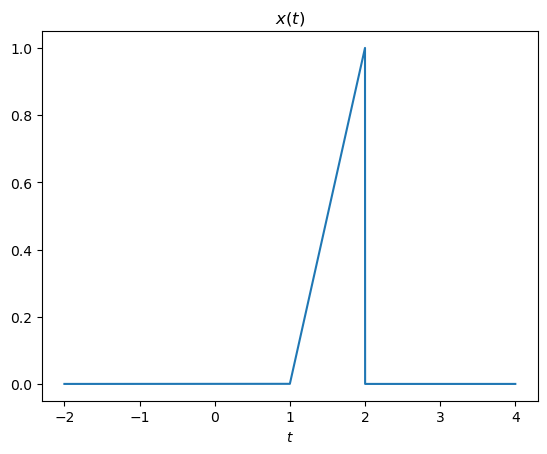

Energia (computacional) =  0.3333833349995961


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Ts = 1e-4
t = np.arange(-2,4,Ts)
u = 1*(t>=1)
u1 = 1*(t>=2)
x = (u - u1)*(t - 1)

plt.plot(t,x)
plt.xlabel('$t$')
plt.title('$x(t)$')
plt.show()

Ex = Ts*np.sum(x**2)   #Aproximação para a Energia
print('Energia (computacional) = ', Ex)

Energia (analitica):


\begin{aligned}
\Rightarrow \int_{-\infty}^{\infty} (t - 1)^2 \, dt &= \Rightarrow \int_{1}^{2} t^2 - 2t + 1 \, dt \\
&= \Big[ \frac{t^3}{3} - t^2 + t \Big]_{1}^{2} \\
&= \frac{8}{3} - 4 + 2 - (\frac{1}{3} - 1 + 1) \\
&= \frac{8 - 1 - 6}{3} = \frac{1}{3}
\end{aligned}


**Resultado final:**

\[
\boxed{10}
\]


## 2

### a)
$$
x(t) = \begin{cases}
2 & -1.5 \leq t \leq 0 \\
2e^{\frac{-t}{2}} & 0 < t \leq 3 \\
0 & \mathrm{c.c.}
\end{cases}
$$

$$
x(t) = 2(u(t + 1.5) - u(t)) + 2e^{\frac{-t}{2}}(u(t) - u(t - 3))
$$

### b)


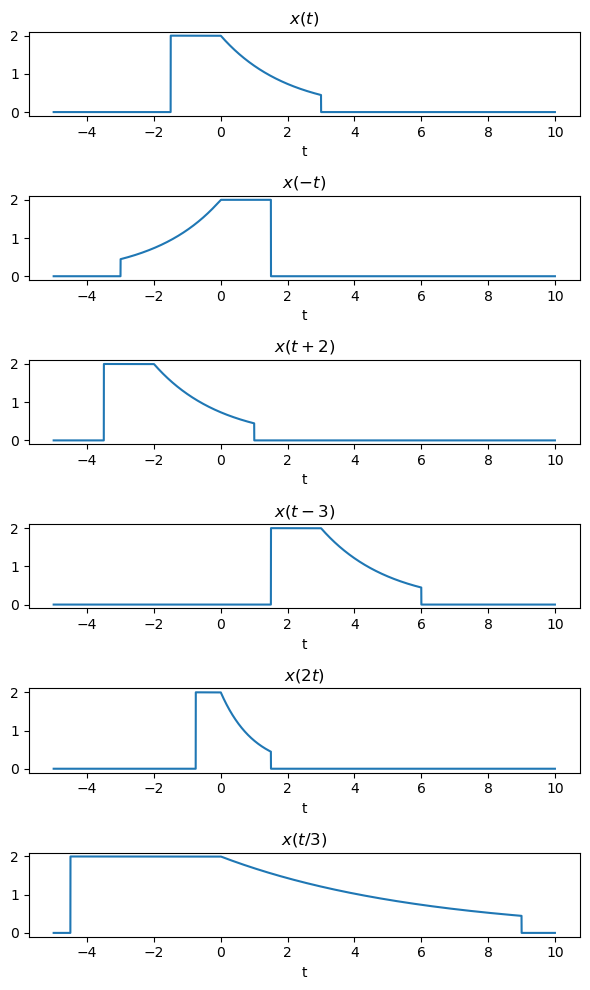

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def sinal2(t):
    u = 1*(t>=-1.5)
    u1 = 1*(t>=0)
    u2 = 1*(t>=3)
    x = (u - u1)*(2) + (u1 - u2)*2*np.exp(-t/2)
    return x


Ts = 1e-4
t = np.arange(-5,10,Ts)

x = sinal2(t)

x1 = sinal2(-t)
x2 = sinal2(t+2)
x3 = sinal2(t-3)
x4 = sinal2(2*t)
x5 = sinal2(t/3)

plt.figure(figsize=(6,10))
plt.subplot(6,1,1)
plt.plot(t,x)
plt.xlabel('t')
plt.title('$x(t)$')

plt.subplot(6,1,2)
plt.plot(t,x1)
plt.xlabel('t')
plt.title('$x(-t)$')

plt.subplot(6,1,3)
plt.plot(t,x2)
plt.xlabel('t')
plt.title('$x(t + 2)$')

plt.subplot(6,1,4)
plt.plot(t,x3)
plt.xlabel('t')
plt.title('$x(t - 3)$')

plt.subplot(6,1,5)
plt.plot(t,x4)
plt.xlabel('t')
plt.title('$x(2t)$')

plt.subplot(6,1,6)
plt.plot(t,x5)
plt.xlabel('t')
plt.title('$x(t/3)$')

plt.tight_layout()
plt.show()

## 3

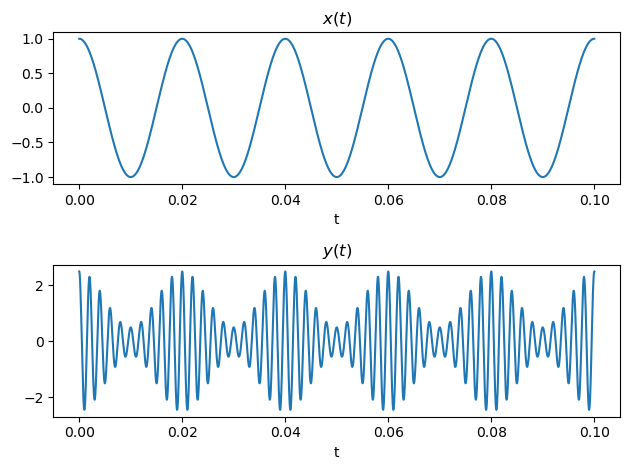

In [25]:
import numpy as np
import matplotlib.pyplot as plt

Ts = 1e-6
t = np.arange(0,0.1,Ts)

Fm = 50
x = np.cos(2*np.pi*Fm*t)

Fc = 500
A = 1.5
y = (A + x)*np.cos(2*np.pi*Fc*t)

plt.subplot(2,1,1)
plt.plot(t,x)
plt.xlabel('t')
plt.title('$x(t)$')

plt.subplot(2,1,2)
plt.plot(t,y)
plt.xlabel('t')
plt.title('$y(t)$')

plt.tight_layout()
plt.show()

## 4

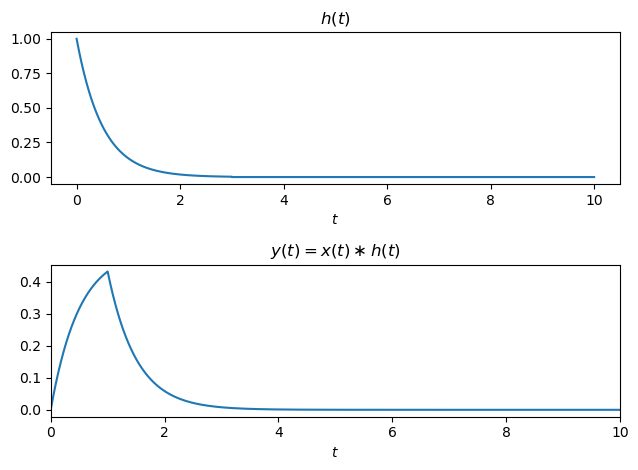

In [44]:
import numpy as np
import matplotlib.pyplot as plt

Ts = 1e-4
t_min = 0
t_max = 10
t = np.arange(t_min,t_max,Ts)

x = ((0 < t) & (t < 1))*1
h = (t >= 0)*np.exp(-2*t)
hp = (t >= 0)*np.exp(-2*t)*(t<=3)

y = Ts*np.convolve(x,h)
ty = np.arange(2*t_min,2*t_max-Ts,Ts)   #A convolução aumenta o tamanho do vetor


plt.subplot(2,1,1)
plt.plot(t,hp)
plt.title('$h(t)$')
plt.xlabel('$t$')
plt.tight_layout()

plt.subplot(2,1,2)
plt.plot(ty,y)
plt.xlim([t_min,t_max])    #Serve apenas para apresentar o resultado da convolucao no internavalo tmin ate tmax
plt.title('$y(t) = x(t) \\ast h(t)$')
plt.xlabel('$t$')
plt.tight_layout()
plt.show()

## 5

In [35]:
import sympy as sympy
sympy.init_printing()    #Melhora a apresentacao das ED

t = sympy.symbols('t')   #Cria a variavel simbolica t
y = sympy.Function('y')  #Cria uma funcao y

x = 6*sympy.exp(-3*t)

eq = sympy.diff(y(t),t,t) + 7*sympy.diff(y(t),t) + 10*y(t) - sympy.diff(x,t) - 6*x
sol = sympy.dsolve(eq,ics={y(t).subs(t,0):6, y(t).diff(t).subs(t, 0):-4})
sol

## 6

In [39]:
import sympy as sympy
sympy.init_printing()    #Melhora a apresentacao das ED

t = sympy.symbols('t')   #Cria a variavel simbolica t
y = sympy.Function('y')  #Cria uma funcao y

eq = sympy.diff(y(t),t,t) + 4*sympy.diff(y(t),t) + 3*y(t)   #Desejamos apenas a resposta natural
yh = sympy.dsolve(eq,ics={y(t).subs(t,0):0, y(t).diff(t).subs(t, 0):1})
h = sympy.diff(yh.rhs,t)
h

In [3]:
import sympy as sympy
t = sympy.symbols('t')
y = sympy.Function('y')

# 1. Encontrar h_op(t): A resposta do sistema a um impulso unitário no LADO ESQUERDO.
# Ela satisfaz a EDO homogênea com C.I. forçadas: y(0)=0, y'(0)=1
LHS_eq = sympy.diff(y(t), t, t) + 4*sympy.diff(y(t), t) + 3*y(t)
h_op_sol = sympy.dsolve(LHS_eq, y(t), ics={y(t).subs(t, 0): 0, y(t).diff(t).subs(t, 0): 1})

# Extrai a expressão de h_op(t)
h_op = h_op_sol.rhs

# 2. Aplicar a relação: h(t) = (d/dt)h_op(t) + 5*h_op(t)
# Onde d/dt + 5 é o operador do Lado Direito da EDO.
dh_op = sympy.diff(h_op, t)
h_t_expr = dh_op + 5 * h_op

# 3. Adicionar o termo do impulso (necessário quando o grau do numerador é igual ao do denominador)
# A função é sempre multiplicada pela função degrau unitário u(t) para causalidade.
h_t = h_t_expr + 1 * sympy.DiracDelta(t) 
# Note: o fator 1 vem de (b_m / a_n), que é (1/1) neste caso.

# Resposta final seria h_t_expr (para t>0)
h_t

4*(1/2 - exp(-2*t)/2)*exp(-t) + DiracDelta(t) + exp(-3*t)